In [ ]:
import glob
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Epsilons must match simulation_scenario1_final.py / submit_sim1_final.slurm
epsilons   = [0.25, 0.30, 0.35, 0.40, 0.45]
eps_keys   = [f"{e:g}" for e in epsilons]
eps_labels = [f"ε={e:g}" for e in epsilons]

result_paths = sorted(glob.glob("./output/sim1_final_result*.pkl"))
if not result_paths:
    raise FileNotFoundError("No scenario-1 final result files found in ./output/")

data = []
for path in result_paths:
    with open(path, "rb") as f:
        data.extend(pickle.load(f))

print(f"Loaded {len(data)} replications from {len(result_paths)} files")
print("epsilons:", epsilons)


In [ ]:
# MAP_Q and initial RPS diagnostics
map_q_vals   = [x["map_q"]   for x in data]
n_prior_vals = [x["n_prior"] for x in data]

print(f"MAP_Q   — mean={np.mean(map_q_vals):.4f}  std={np.std(map_q_vals):.4f}  "
      f"[{np.min(map_q_vals):.4f}, {np.max(map_q_vals):.4f}]")
print(f"n_prior — mean={np.mean(n_prior_vals):.1f}  "
      f"[{int(np.min(n_prior_vals))}, {int(np.max(n_prior_vals))}]")
print()

rows = []
for x in data:
    map_q = x["map_q"]
    for key, eps in zip(eps_keys, epsilons):
        rows.append({
            "eps": eps,
            "theta": map_q * (1 + eps),
            "rps_n": x.get(f"RPS_{key}_n_states", np.nan),
            "pb_n":  x.get(f"PB_{key}_n_states",  np.nan),
        })

diag = pd.DataFrame(rows)
diag.groupby("eps")[["theta", "rps_n", "pb_n"]].mean().round(4)


## Accuracy plots (vs exact posterior)

In [ ]:
RPS_mean  = {k: [] for k in eps_keys}
AIS_mean  = {k: [] for k in eps_keys}
PB_mean   = {k: [] for k in eps_keys}
MCMC_mean = []

RPS_q025  = {k: [] for k in eps_keys}
AIS_q025  = {k: [] for k in eps_keys}
PB_q025   = {k: [] for k in eps_keys}
MCMC_q025 = []

RPS_q975  = {k: [] for k in eps_keys}
AIS_q975  = {k: [] for k in eps_keys}
PB_q975   = {k: [] for k in eps_keys}
MCMC_q975 = []

for x in data:
    ref      = x["exact"]
    ref_q025 = x["exact_quantiles"]["0.025"]
    ref_q975 = x["exact_quantiles"]["0.975"]

    MCMC_mean.append(np.sum(np.abs(x["MCMC"]                       - ref)))
    MCMC_q025.append(np.sum(np.abs(x["MCMC_quantiles"]["0.025"]    - ref_q025)))
    MCMC_q975.append(np.sum(np.abs(x["MCMC_quantiles"]["0.975"]    - ref_q975)))

    for key in eps_keys:
        RPS_mean[key].append(np.sum(np.abs(np.asarray(x[f"RPS_{key}"])               - ref)))
        AIS_mean[key].append(np.sum(np.abs(np.asarray(x[f"AIS_{key}"])               - ref)))
        PB_mean[key].append( np.sum(np.abs(np.asarray(x[f"PB_{key}"])                - ref)))
        RPS_q025[key].append(np.sum(np.abs(x[f"RPS_{key}_quantiles"]["0.025"]        - ref_q025)))
        AIS_q025[key].append(np.sum(np.abs(x[f"AIS_{key}_quantiles"]["0.025"]        - ref_q025)))
        PB_q025[key].append( np.sum(np.abs(x[f"PB_{key}_quantiles"]["0.025"]         - ref_q025)))
        RPS_q975[key].append(np.sum(np.abs(x[f"RPS_{key}_quantiles"]["0.975"]        - ref_q975)))
        AIS_q975[key].append(np.sum(np.abs(x[f"AIS_{key}_quantiles"]["0.975"]        - ref_q975)))
        PB_q975[key].append( np.sum(np.abs(x[f"PB_{key}_quantiles"]["0.975"]         - ref_q975)))


In [ ]:
ais_color  = "#4878CF"
rps_color  = "#D65F5F"
pb_color   = "#762a83"
mcmc_color = "#4DAC26"
exact_color = "#8c8c8c"

n = len(eps_keys)
eps_pos   = np.arange(1, n + 1)
mcmc_pos  = [n + 2]

def aligned_boxplot(ax, values, positions, color, width=0.48, alpha=0.32):
    bp = ax.boxplot(values, positions=positions, widths=width,
                    patch_artist=True, showfliers=False,
                    medianprops=dict(color=color, linewidth=2),
                    whiskerprops=dict(color=color, linewidth=1.2),
                    capprops=dict(color=color, linewidth=1.2))
    for patch in bp["boxes"]:
        patch.set_facecolor(color); patch.set_edgecolor(color); patch.set_alpha(alpha)
    return bp

def mean_diamonds(ax, values, positions, color, offset=0.0):
    means = [np.nanmean(v) for v in values]
    ax.plot(np.asarray(positions) + offset, means, "D", color=color,
            markersize=5, linestyle="None", zorder=5)

panel_data = [
    ("Posterior Mean", RPS_mean,  AIS_mean,  PB_mean,  MCMC_mean),
    ("2.5% Quantile",  RPS_q025,  AIS_q025,  PB_q025,  MCMC_q025),
    ("97.5% Quantile", RPS_q975,  AIS_q975,  PB_q975,  MCMC_q975),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (title, rps_d, ais_d, pb_d, mcmc_vals) in zip(axes, panel_data):
    rps_v  = [rps_d[k]  for k in eps_keys]
    ais_v  = [ais_d[k]  for k in eps_keys]
    pb_v   = [pb_d[k]   for k in eps_keys]

    aligned_boxplot(ax, rps_v,      eps_pos,  rps_color,  width=0.60, alpha=0.28)
    aligned_boxplot(ax, ais_v,      eps_pos,  ais_color,  width=0.38, alpha=0.34)
    aligned_boxplot(ax, pb_v,       eps_pos,  pb_color,   width=0.20, alpha=0.40)
    aligned_boxplot(ax, [mcmc_vals],mcmc_pos, mcmc_color, width=0.50, alpha=0.45)

    mean_diamonds(ax, rps_v,       eps_pos,  rps_color)
    mean_diamonds(ax, ais_v,       eps_pos,  ais_color)
    mean_diamonds(ax, pb_v,        eps_pos,  pb_color)
    mean_diamonds(ax, [mcmc_vals], mcmc_pos, mcmc_color)

    tick_pos    = list(eps_pos) + mcmc_pos
    tick_labels = eps_labels + ["MCMC"]
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_labels, rotation=30, ha="right", fontsize=10)
    ax.axvline(n + 1, color="gray", linestyle=":", linewidth=0.8, alpha=0.6)
    ax.set_xlim(0.3, n + 2.7)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=8)
    ax.set_ylabel("$L_1$ error from exact", fontsize=11)
    ax.grid(axis="y", linestyle=":", alpha=0.4)

legend_elements = [
    mpatches.Patch(facecolor=rps_color,  alpha=0.28, label="RPS"),
    mpatches.Patch(facecolor=ais_color,  alpha=0.34, label="AIS"),
    mpatches.Patch(facecolor=pb_color,   alpha=0.40, label="PB"),
    mpatches.Patch(facecolor=mcmc_color, alpha=0.45, label="MCMC"),
    plt.Line2D([0], [0], marker="D", color="gray", markersize=5,
               linestyle="None", label="Mean"),
]
fig.legend(handles=legend_elements, loc="upper center", ncol=5,
           frameon=True, bbox_to_anchor=(0.5, 1.03))
fig.suptitle("Scenario 1 Accuracy Relative to Exact Posterior", fontsize=15,
             fontweight="bold", y=1.08)
plt.tight_layout()
plt.savefig("../Figures/simulation1_errors.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# PB overlap diagnostic: how many states does PB add beyond the initial RPS?
from rashomon import AIS as AIS_mod

rows = []
for rep, x in enumerate(data):
    for key in eps_keys:
        rps_states = x.get(f"RPS_{key}_states", [])
        pb_states  = x.get(f"PB_{key}_states",  [])
        pb_logw    = np.asarray(x.get(f"PB_{key}_logw", []), dtype=float)
        rps_sigs   = {AIS_mod.state_signature(s) for s in rps_states}
        pb_sigs    = [AIS_mod.state_signature(s) for s in pb_states]
        is_old     = np.array([sig in rps_sigs for sig in pb_sigs], dtype=bool)
        if len(pb_logw):
            w = np.exp(pb_logw - np.max(pb_logw)); w /= w.sum()
            new_mass = float(np.sum(w[~is_old]))
        else:
            new_mass = np.nan
        rows.append({"rep": rep, "eps": float(key),
                     "rps_n": len(rps_states), "pb_n": len(pb_states),
                     "pb_new_n": int(np.sum(~is_old)),
                     "pb_new_mass": new_mass})

pb_diag = pd.DataFrame(rows)
pb_diag.groupby("eps")[["rps_n", "pb_n", "pb_new_n", "pb_new_mass"]].mean().round(3)


CI overlap plot

In [30]:
def ci_overlap_frac(a_m, b_m, a_ref, b_ref):
    intersection = np.maximum(0, np.minimum(b_m, b_ref) - np.maximum(a_m, a_ref))
    ref_len = b_ref - a_ref
    return np.where(ref_len > 0, intersection / ref_len, np.nan)

RPS_overlap  = {k: [] for k in eps_keys}
AIS_overlap  = {k: [] for k in eps_keys}
PB_overlap   = {k: [] for k in eps_keys}
MCMC_overlap = []

for x in data:
    exact_lo = x["exact_quantiles"]["0.025"]
    exact_hi = x["exact_quantiles"]["0.975"]
    mcmc_lo  = x["MCMC_quantiles"]["0.025"]
    mcmc_hi  = x["MCMC_quantiles"]["0.975"]
    MCMC_overlap.append(np.nanmean(ci_overlap_frac(mcmc_lo, mcmc_hi, exact_lo, exact_hi)))
    for key in eps_keys:
        rps_lo = x[f"RPS_{key}_quantiles"]["0.025"]; rps_hi = x[f"RPS_{key}_quantiles"]["0.975"]
        ais_lo = x[f"AIS_{key}_quantiles"]["0.025"]; ais_hi = x[f"AIS_{key}_quantiles"]["0.975"]
        pb_lo  = x[f"PB_{key}_quantiles"]["0.025"];  pb_hi  = x[f"PB_{key}_quantiles"]["0.975"]
        RPS_overlap[key].append(np.nanmean(ci_overlap_frac(rps_lo, rps_hi, exact_lo, exact_hi)))
        AIS_overlap[key].append(np.nanmean(ci_overlap_frac(ais_lo, ais_hi, exact_lo, exact_hi)))
        PB_overlap[key].append( np.nanmean(ci_overlap_frac(pb_lo,  pb_hi,  exact_lo, exact_hi)))


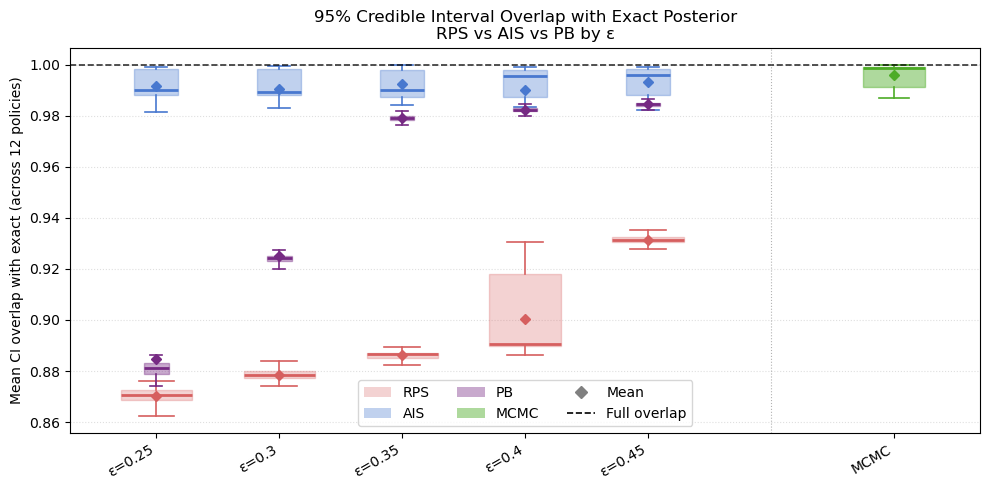

In [31]:
fig, ax = plt.subplots(figsize=(10, 5))

aligned_boxplot(ax, [RPS_overlap[k]  for k in eps_keys], eps_pos, rps_color,  width=0.58, alpha=0.28)
aligned_boxplot(ax, [AIS_overlap[k]  for k in eps_keys], eps_pos, ais_color,  width=0.36, alpha=0.34)
aligned_boxplot(ax, [PB_overlap[k]   for k in eps_keys], eps_pos, pb_color,   width=0.20, alpha=0.40)
aligned_boxplot(ax, [MCMC_overlap],                       mcmc_pos, mcmc_color, width=0.50, alpha=0.45)

mean_diamonds(ax, [RPS_overlap[k]  for k in eps_keys], eps_pos,  rps_color)
mean_diamonds(ax, [AIS_overlap[k]  for k in eps_keys], eps_pos,  ais_color)
mean_diamonds(ax, [PB_overlap[k]   for k in eps_keys], eps_pos,  pb_color)
mean_diamonds(ax, [MCMC_overlap],                       mcmc_pos, mcmc_color)

ax.axhline(1.0, color="black", linestyle="--", linewidth=1.2, alpha=0.8)
ax.set_xticks(list(eps_pos) + mcmc_pos)
ax.set_xticklabels(eps_labels + ["MCMC"], rotation=30, ha="right")
ax.axvline(n + 1, color="gray", linestyle=":", linewidth=0.8, alpha=0.6)
ax.set_xlim(0.3, n + 2.7)
ax.set_ylabel("Mean CI overlap with exact (across 12 policies)")
ax.set_title("95% Credible Interval Overlap with Exact Posterior\nRPS vs AIS vs PB by ε")
ax.grid(axis="y", linestyle=":", alpha=0.4)

legend_elements = [
    mpatches.Patch(facecolor=rps_color,  alpha=0.28, label="RPS"),
    mpatches.Patch(facecolor=ais_color,  alpha=0.34, label="AIS"),
    mpatches.Patch(facecolor=pb_color,   alpha=0.40, label="PB"),
    mpatches.Patch(facecolor=mcmc_color, alpha=0.45, label="MCMC"),
    plt.Line2D([0], [0], marker="D", color="gray", markersize=6, linestyle="None", label="Mean"),
    plt.Line2D([0], [0], color="black", linestyle="--", linewidth=1.2, label="Full overlap"),
]
ax.legend(handles=legend_elements, ncol=3)
plt.tight_layout()
plt.savefig("../Figures/simulation1_ci_overlap.png", dpi=150, bbox_inches="tight")
plt.show()


In [86]:
import numpy as np

def hausdorff(lo_m, hi_m, lo_ref, hi_ref):
    """max(|lo_m - lo_ref|, |hi_m - hi_ref|) per policy."""
    return np.maximum(np.abs(lo_m - lo_ref), np.abs(hi_m - hi_ref))

def scaled_wasserstein(lo_m, hi_m, lo_ref, hi_ref):
    """((m-m*)/w*)^2 + ((w-w*)/w*)^2 per policy, scaled by reference half-width."""
    m     = (lo_m  + hi_m)  / 2;  w     = (hi_m  - lo_m)  / 2
    m_ref = (lo_ref + hi_ref) / 2; w_ref = (hi_ref - lo_ref) / 2
    loc   = ((m - m_ref) / w_ref) ** 2
    scale = ((w - w_ref) / w_ref) ** 2
    return loc + scale

thetas = [7.8,8,8.2,8.4,8.6]

HD_RPS   = {f"{t}": [] for t in thetas}
HD_AIS   = {f"{t}": [] for t in thetas}
HD_MCMC  = []
SW_RPS   = {f"{t}": [] for t in thetas}
SW_AIS   = {f"{t}": [] for t in thetas}
SW_MCMC  = []

for x in data:
    lo_ref = x['exact_quantiles']['0.025']
    hi_ref = x['exact_quantiles']['0.975']
    lo_mc  = x['MCMC_quantiles']['0.025']
    hi_mc  = x['MCMC_quantiles']['0.975']
    HD_MCMC.append(np.mean(hausdorff(lo_mc, hi_mc, lo_ref, hi_ref)))
    SW_MCMC.append(np.mean(scaled_wasserstein(lo_mc, hi_mc, lo_ref, hi_ref)))
    for theta in thetas:
        lo_r = x[f'RPS_{theta}_quantiles']['0.025']; hi_r = x[f'RPS_{theta}_quantiles']['0.975']
        lo_a = x[f'AIS_{theta}_quantiles']['0.025']; hi_a = x[f'AIS_{theta}_quantiles']['0.975']
        HD_RPS[f"{theta}"].append(np.mean(hausdorff(lo_r, hi_r, lo_ref, hi_ref)))
        HD_AIS[f"{theta}"].append(np.mean(hausdorff(lo_a, hi_a, lo_ref, hi_ref)))
        SW_RPS[f"{theta}"].append(np.mean(scaled_wasserstein(lo_r, hi_r, lo_ref, hi_ref)))
        SW_AIS[f"{theta}"].append(np.mean(scaled_wasserstein(lo_a, hi_a, lo_ref, hi_ref)))


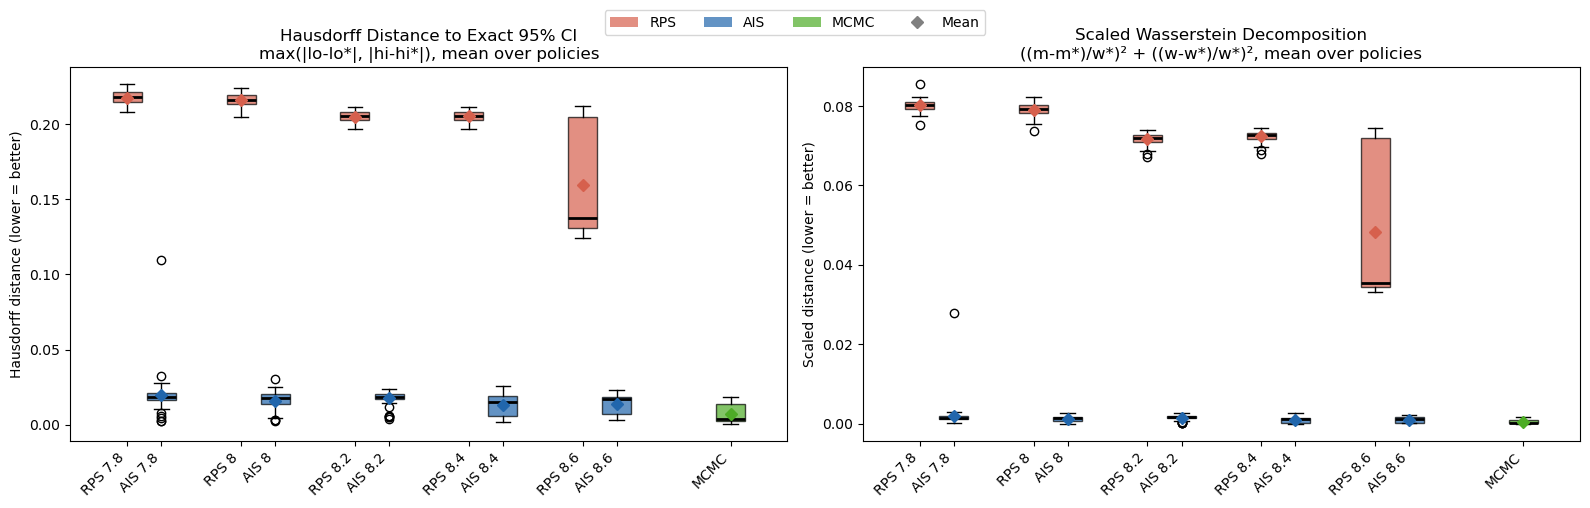

In [87]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def side_by_side_boxplot(ax, rps_dict, ais_dict, mcmc_list, title, ylabel):
    cols = list(rps_dict.keys())
    x_pos = np.arange(len(cols))

    aligned_boxplot(ax, [rps_dict[c] for c in cols], x_pos, "#d6604d", width=0.58, alpha=0.28)
    aligned_boxplot(ax, [ais_dict[c] for c in cols], x_pos, "#2166ac", width=0.36, alpha=0.34)
    aligned_boxplot(ax, [mcmc_list], [len(cols)], "#4dac26", width=0.5, alpha=0.45)

    mean_diamonds(ax, [rps_dict[c] for c in cols], x_pos, "#d6604d")
    mean_diamonds(ax, [ais_dict[c] for c in cols], x_pos, "#2166ac")
    mean_diamonds(ax, [mcmc_list], [len(cols)], "#4dac26")

    ax.set_xticks(list(x_pos) + [len(cols)])
    ax.set_xticklabels([f"θ={c}" for c in cols] + ["MCMC"], rotation=30, ha="right")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", linestyle=":", alpha=0.4)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

side_by_side_boxplot(axes[0], HD_RPS, HD_AIS, HD_MCMC,
    "Hausdorff Distance to Exact 95% CI\nmax(|lo-lo*|, |hi-hi*|), mean over policies",
    "Hausdorff distance (lower = better)")

side_by_side_boxplot(axes[1], SW_RPS, SW_AIS, SW_MCMC,
    "Scaled Wasserstein Decomposition\n((m-m*)/w*)² + ((w-w*)/w*)², mean over policies",
    "Scaled distance (lower = better)")

legend_elements = [
    mpatches.Patch(facecolor="#d6604d", alpha=0.28, label="RPS"),
    mpatches.Patch(facecolor="#2166ac", alpha=0.34, label="AIS"),
    mpatches.Patch(facecolor="#4dac26", alpha=0.45, label="MCMC"),
    plt.Line2D([0], [0], marker="D", color="gray", markersize=6, linestyle="None", label="Mean"),
]
fig.legend(handles=legend_elements, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout()
plt.show()


Interval scoring rule

In [76]:
import numpy as np

# S_alpha(L, U; theta*) = (U-L) + (2/alpha)(L-theta*)1{theta*<L} + (2/alpha)(theta*-U)1{theta*>U}
def interval_score(L, U, theta_star, alpha=0.05):
    width     = U - L
    undershot = (2/alpha) * np.maximum(0, L - theta_star)
    overshot  = (2/alpha) * np.maximum(0, theta_star - U)
    return width + undershot + overshot

thetas = [7.8, 8, 8.2, 8.4, 8.6]
alpha  = 0.05   # 95% CI

# theta* = exact posterior mean per policy per replication
IS_RPS  = {f"{t}": [] for t in thetas}
IS_AIS  = {f"{t}": [] for t in thetas}
IS_MCMC = []

for x in data:
    theta_star = x['exact_quantiles']["0.5"]          # shape (n_policies,)
    mcmc_lo    = x['MCMC_quantiles']['0.025']
    mcmc_hi    = x['MCMC_quantiles']['0.975']
    IS_MCMC.append(np.sum(interval_score(mcmc_lo, mcmc_hi, theta_star, alpha)))
    for theta in thetas:
        rlo = x[f'RPS_{theta}_quantiles']['0.025']
        rhi = x[f'RPS_{theta}_quantiles']['0.975']
        alo = x[f'AIS_{theta}_quantiles']['0.025']
        ahi = x[f'AIS_{theta}_quantiles']['0.975']
        IS_RPS[f"{theta}"].append(np.sum(interval_score(rlo, rhi, theta_star, alpha)))
        IS_AIS[f"{theta}"].append(np.sum(interval_score(alo, ahi, theta_star, alpha)))


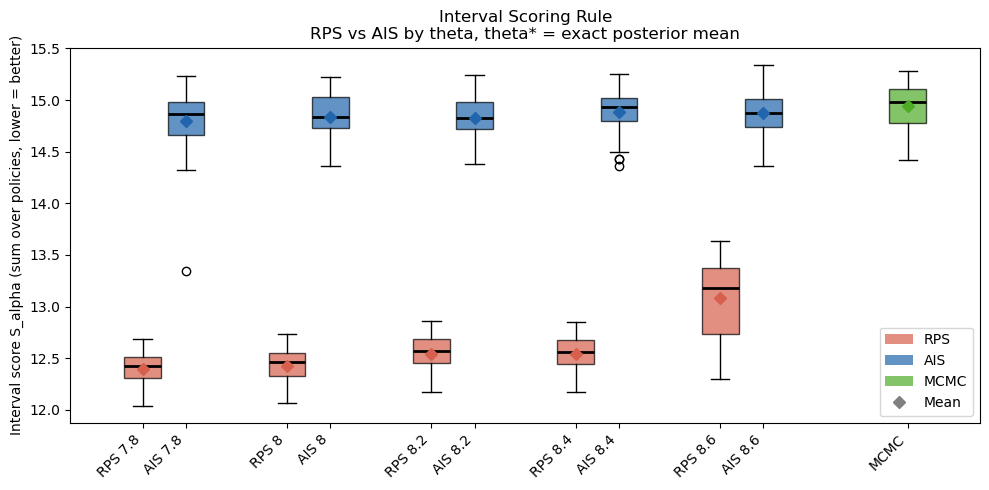

In [77]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

cols = list(IS_RPS.keys())
x_pos = np.arange(len(cols))
fig, ax = plt.subplots(figsize=(10, 5))

aligned_boxplot(ax, [IS_RPS[c] for c in cols], x_pos, "#d6604d", width=0.58, alpha=0.28)
aligned_boxplot(ax, [IS_AIS[c] for c in cols], x_pos, "#2166ac", width=0.36, alpha=0.34)
aligned_boxplot(ax, [IS_MCMC], [len(cols)], "#4dac26", width=0.5, alpha=0.45)

mean_diamonds(ax, [IS_RPS[c] for c in cols], x_pos, "#d6604d")
mean_diamonds(ax, [IS_AIS[c] for c in cols], x_pos, "#2166ac")
mean_diamonds(ax, [IS_MCMC], [len(cols)], "#4dac26")

ax.set_xticks(list(x_pos) + [len(cols)])
ax.set_xticklabels([f"θ={c}" for c in cols] + ["MCMC"], rotation=30, ha="right")
ax.set_ylabel("Interval score S_alpha (sum over policies, lower = better)")
ax.set_title("Interval Scoring Rule\nRPS vs AIS by theta, theta* = exact posterior mean")
ax.grid(axis="y", linestyle=":", alpha=0.4)

legend_elements = [
    mpatches.Patch(facecolor="#d6604d", alpha=0.28, label="RPS"),
    mpatches.Patch(facecolor="#2166ac", alpha=0.34, label="AIS"),
    mpatches.Patch(facecolor="#4dac26", alpha=0.45, label="MCMC"),
    plt.Line2D([0], [0], marker="D", color="gray", markersize=6, linestyle="None", label="Mean"),
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()


In [69]:
exact_width=[]
MCMC_width=[]
RPS_8_width=[]
AIS_8_width=[]
for x in data:
    exact_width.append(np.mean(x["exact_quantiles"]["0.975"]-x["exact_quantiles"]["0.025"]))
    MCMC_width.append(np.mean(x["MCMC_quantiles"]["0.975"]-x["MCMC_quantiles"]["0.025"]))
    AIS_8_width.append(np.mean(x["AIS_8_quantiles"]["0.975"]-x["AIS_8_quantiles"]["0.025"]))
    RPS_8_width.append(np.mean(x["RPS_8_quantiles"]["0.975"]-x["RPS_8_quantiles"]["0.025"]))


{'whiskers': [<matplotlib.lines.Line2D at 0x150fa5d50>,
 'caps': [<matplotlib.lines.Line2D at 0x1510f5dd0>,
 'boxes': [<matplotlib.lines.Line2D at 0x150fa6dd0>,
 'medians': [<matplotlib.lines.Line2D at 0x15109e190>,
 'fliers': [<matplotlib.lines.Line2D at 0x151da7150>,
 'means': []}

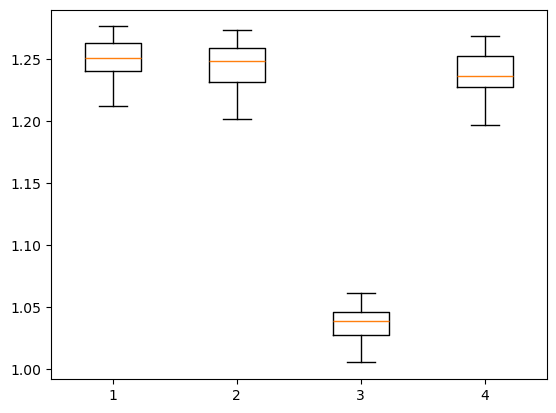

In [70]:

fig, ax = plt.subplots(figsize=(7, 4))
labels = ["Exact", "MCMC", "RPS θ=8", "AIS θ=8"]
values = [exact_width, MCMC_width, RPS_8_width, AIS_8_width]
colors = ["#8c8c8c", "#4dac26", "#d6604d", "#2166ac"]
bp = ax.boxplot(values, positions=np.arange(len(values)), widths=0.5,
                patch_artist=True, showfliers=False,
                medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor(color)
    patch.set_alpha(0.45)
mean_diamonds(ax, values, np.arange(len(values)), "black")
ax.set_xticks(np.arange(len(values)))
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_ylabel("Mean 95% interval width")
ax.grid(axis="y", linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()


In [62]:
data[0]["RPS_8_quantiles"]["0.025"]


array([-0.07938018, -1.01684242, -0.99034923, -2.36827934, -0.09344553,
        0.74705697, -2.52900616, -0.10650948, -0.0925145 , -3.02364461,
       -0.11962633, -0.11127446])

In [63]:
data[0]["RPS_8_quantiles"]["0.975"]


array([ 0.09305617, -0.86934012, -0.84284693, -1.91557572,  2.5404655 ,
        2.5404655 , -1.95605082,  1.25331599,  1.68362523, -2.26848308,
        0.84312272,  1.68362523])

In [72]:
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from copy import deepcopy
from rashomon import hasse, extract_pools, loss, aggregate, AIS, MCMC
lamb=1
theta=8.6
M = 2
R = np.array([4, 3])

num_profiles = 2**M
profiles, profile_map = hasse.enumerate_profiles(M)

all_policies = hasse.enumerate_policies(M, R)
num_policies = len(all_policies)

sigma_00 = None
mu_00 = np.array([0])
# mu_00 = np.array([5])
var_00 = np.array([1])

# Profile (0, 1)
sigma_01 = np.array([[1]])
mu_01 = np.array([-1])
# mu_01 = np.array([10])
var_01 = np.array([1])

# Profile (1, 0)
sigma_10 = np.array([[1, 0]])
mu_10 = np.array([-2, -3])
# mu_10 = np.array([-10, 15])
var_10 = np.array([1, 1])

# Profile (1, 1)
sigma_11 = np.array([[0, 1], [0, np.inf]])
mu_11 = np.array([2, 3, -1, 1])
# mu_11 = np.array([20, 30, 5, 10])
var_11 = np.array([1, 1, 1, 1])

sigma = [sigma_00, sigma_01, sigma_10, sigma_11]
mu = [mu_00, mu_01, mu_10, mu_11]
var = [var_00, var_01, var_10, var_11]

policies_profiles = {}
policies_profiles_masked = {}
policies_ids_profiles = {}
pi_policies = {}
pi_pools = {}
for k, profile in enumerate(profiles):

    policies_temp = [(i, x) for i, x in enumerate(all_policies) if hasse.policy_to_profile(x) == profile]
    unzipped_temp = list(zip(*policies_temp))
    policies_ids_k = list(unzipped_temp[0])
    policies_k = list(unzipped_temp[1])
    policies_profiles[k] = deepcopy(policies_k)
    policies_ids_profiles[k] = policies_ids_k

    profile_mask = list(map(bool, profile))

    # Mask the empty arms
    for idx, pol in enumerate(policies_k):
        policies_k[idx] = tuple([pol[i] for i in range(M) if profile_mask[i]])
    policies_profiles_masked[k] = policies_k

    if np.sum(profile) > 0:
        pi_pools_k, pi_policies_k = extract_pools.extract_pools(policies_k, sigma[k])
        if len(pi_pools_k.keys()) != mu[k].shape[0]:
            print(f"Profile {k}. Expected {len(pi_pools_k.keys())} pools. Received {mu[k].shape[0]} means.")
        pi_policies[k] = pi_policies_k
        # pi_pools_k has indicies that match with policies_profiles[k]
        # Need to map those indices back to all_policies
        pi_pools[k] = {}
        for x, y in pi_pools_k.items():
            y_full = [policies_profiles[k][i] for i in y]
            y_agg = [all_policies.index(i) for i in y_full]
            pi_pools[k][x] = y_agg
    else:
        pi_policies[k] = {0: 0}
        pi_pools[k] = {0: [0]}

def generate_data(mu, var, n_per_pol, all_policies, pi_policies, M):
    num_data = num_policies * n_per_pol
    X = np.zeros(shape=(num_data, M))
    D = np.zeros(shape=(num_data, 1), dtype='int_')
    y = np.zeros(shape=(num_data, 1))

    idx_ctr = 0
    for k, profile in enumerate(profiles):
        policies_k = policies_profiles[k]

        for idx, policy in enumerate(policies_k):
            policy_idx = [i for i, x in enumerate(all_policies) if x == policy]

            pool_id = pi_policies[k][idx]
            mu_i = mu[k][pool_id]
            var_i = var[k][pool_id]
            y_i = np.random.normal(mu_i, var_i, size=(n_per_pol, 1))

            start_idx = idx_ctr * n_per_pol
            end_idx = (idx_ctr + 1) * n_per_pol

            X[start_idx:end_idx, ] = policy
            D[start_idx:end_idx, ] = policy_idx[0]
            y[start_idx:end_idx, ] = y_i

            idx_ctr += 1

    return X, D, y

num_samples_per_feature = 500
length = []
X, D, y = generate_data(mu, var, num_samples_per_feature, all_policies, pi_policies, M)
policy_means = loss.compute_policy_means(D, y, num_policies)
prof_idx_of_policy, profiles = AIS.build_profile_index_of_policy(all_policies, hasse.policy_to_profile)
# for iter in range(1,51):
#     np.random.seed(iter*42)
#     X, D, y = generate_data(mu, var, num_samples_per_feature, all_policies, pi_policies, M)
#     policy_means = loss.compute_policy_means(D, y, num_policies)
#     prof_idx_of_policy, profiles = AIS.build_profile_index_of_policy(all_policies, hasse.policy_to_profile)

#     def score_s(state):
#                 Q = AIS.global_loss_raw(
#                     state=state,
#                     D=D, y=y, M=M, R=R,
#                     prof_idx_of_policy = prof_idx_of_policy,
#                     policies=all_policies,
#                     policy_means=policy_means,
#                     reg=lamb, normalize=0,
#                     lattice_edges=None,
#                 )
#                 return float(np.exp(-Q))

#     H = np.inf
#     R_set, R_profiles = aggregate.RAggregate(M, R, H, D, y, theta, reg=lamb, verbose=True)

#     anchors = AIS.build_anchor_states(R_set, R_profiles, M, R)
#     prof_idx_of_policy, profiles = AIS.build_profile_index_of_policy(all_policies, hasse.policy_to_profile)

#     RPS_states = AIS.raggregate_to_states((R_set, R_profiles), profiles)
#     length.append(len(RPS_states))


In [110]:
np.min(length)


np.int64(27)

In [85]:
prob = [score_s(A) for A in RPS_states]


In [63]:
ais_out = AIS.run_ais_streaming_from_data(
                M, 
                R, 
                H, 
                D, 
                y, 
                theta, 
                reg=lamb,
                eps1=0.5,
                eps2=0.75,
                all_policies=all_policies,
                score_s=score_s,
                out_dir="./output_files",
                cfg = cfg,
            )


(0, 0) 7.713983213235162
Profile (0, 0) has 1 objects in Rashomon set
(0, 1) 7.787866083122113
Adaptive
Profile (0, 1) took 0.002752065658569336 s adaptively
Profile (0, 1) has 2 objects in Rashomon set
(1, 0) 7.861153034821504
Adaptive
Profile (1, 0) took 0.003144979476928711 s adaptively
Profile (1, 0) has 4 objects in Rashomon set
(1, 1) 8.129868070487802
Adaptive
Profile (1, 1) took 0.013110160827636719 s adaptively
Profile (1, 1) has 8 objects in Rashomon set
Finding feasible combinations
Min = 6.104129726871667, Max = 12.96904319944447
Running pilot adaptive ladder
Adaptive ladder has 6 levels; first 10: [0.   0.05 0.15 0.35 0.75 1.  ]
Per-step ESS ratios (len = 5 ): [1.0, 0.9913673317344911, 0.9661198469626824, 0.9435768657754946, 0.9865325923648947]


In [25]:
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import rashomon
importlib.reload(rashomon.MCMC)

from copy import deepcopy
from rashomon import hasse, extract_pools, loss, aggregate, AIS, MCMC
# mcmc_res = MCMC.load_mcmc_res_from_jsonl("./output_files/mcmc_samples1.jsonl")

# log_weight = np.log(np.repeat(1/len(mcmc_res["samples"]), len(mcmc_res["samples"])))

start = time.time()
mcmc_summ2 = MCMC.quantiles_for_all_policies(
    mcmc_res["samples"],
    log_weight,
    D, y,                     # D[:,0] = global policy id; y is (N,) or (N,1)
    M,
    all_policies,                 # global policies list (len P)
    prof_idx_of_policy,       # length-P array: global policy id -> profile k
    R,                    # per-arm levels (len M)
    lattice_edges=None,
    mu0=0.0, kappa0=1.0, alpha0=2.0, beta0=2.0,
    p=[0.025,0.5,0.975], 
    seed=None
)
end = time.time()
print(end-start)

# start = time.time()
# mcmc_summ = MCMC.quantiles_for_all_policies_root(
#     mcmc_res["samples"],
#     log_weight,
#     D, y,                     # D[:,0] = global policy id; y is (N,) or (N,1)
#     M,
#     all_policies,                 # global policies list (len P)
#     prof_idx_of_policy,       # length-P array: global policy id -> profile k
#     R,                    # per-arm levels (len M)
#     lattice_edges=None,
#     mu0=0.0, kappa0=1.0, alpha0=2.0, beta0=2.0,
#     p=[0.025,0.5,0.975], 
#     seed=None
# )
# end = time.time()
# print(end-start)


57.30595302581787


In [29]:
mcmc_summ["0.025"]-mcmc_summ2["0.025"]


array([-3.62102892e-09, -8.24176283e-10, -1.81870696e-09,  3.04001180e-09,
        4.06294443e-12, -1.86928351e-09,  3.21787041e-09, -2.16930185e-09,
        4.28895661e-09,  3.85105459e-09,  2.49540189e-09,  2.00185052e-09])

In [28]:
mcmc_summ["0.5"]-mcmc_summ2["0.5"]


array([ 4.04596083e-09, -3.75893872e-10,  5.80138881e-09, -2.29982122e-09,
       -2.61231126e-09,  4.26696523e-09, -5.99151395e-10, -3.08997317e-09,
       -2.32010733e-09, -2.38328246e-09, -6.07028178e-11,  4.07994383e-09])

In [31]:
for theta in [7.8, 8, 8.2, 8.4, 8.6]:
    H = np.inf
    R_set, R_profiles = aggregate.RAggregate(M, R, H, D, y, theta, reg=lamb, verbose=True)
    print(len(R_set))


(0, 0) 6.885645763374477
Profile (0, 0) has 1 objects in Rashomon set
(0, 1) 6.9520786022477195
Adaptive
Profile (0, 1) took 0.001474142074584961 s adaptively
Profile (0, 1) has 2 objects in Rashomon set
(1, 0) 7.0599964756153115
Adaptive
Profile (1, 0) took 0.0030837059020996094 s adaptively
Profile (1, 0) has 4 objects in Rashomon set
(1, 1) 7.280153286180922
Adaptive
Profile (1, 1) took 0.013002872467041016 s adaptively
Profile (1, 1) has 8 objects in Rashomon set
Finding feasible combinations
Min = 6.123715610025325, Max = 13.007375290860523
14
(0, 0) 7.085645763374477
Profile (0, 0) has 1 objects in Rashomon set
(0, 1) 7.15207860224772
Adaptive
Profile (0, 1) took 0.0016639232635498047 s adaptively
Profile (0, 1) has 2 objects in Rashomon set
(1, 0) 7.259996475615312
Adaptive
Profile (1, 0) took 0.0030999183654785156 s adaptively
Profile (1, 0) has 4 objects in Rashomon set
(1, 1) 7.480153286180922
Adaptive
Profile (1, 1) took 0.01302790641784668 s adaptively
Profile (1, 1) has 8 